# NIH Chest X-Ray Multi-Label Disease Classification
## Using Pre-trained CNN Backbones: ResNet-50, EfficientNet-B3, DenseNet-121

**Project Description:**  
This project builds a multi-label image classification system to detect 14 thoracic diseases from chest X-ray images using the NIH ChestX-ray14 dataset. We compare three pre-trained CNN backbones and analyze the impact of regularization techniques (Dropout, Early Stopping, Weight Decay).

**Dataset:** NIH ChestX-ray14 - 112,120 frontal-view X-rays from 30,805 unique patients  
**Task:** Multi-label classification (each image can have multiple disease labels)  
**Labels:** Atelectasis, Cardiomegaly, Effusion, Infiltration, Mass, Nodule, Pneumonia, Pneumothorax, Consolidation, Edema, Emphysema, Fibrosis, Pleural Thickening, Hernia

**Submitted by:** Karan Kumar (023-22-0122), Farhan Qadir(023-22-0082), Ali Raza(023-21-0115)

## 1. Setup & Imports

In [1]:
import os
import glob
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import defaultdict
import json
import time
import copy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler

import torchvision
import torchvision.transforms as transforms
from torchvision import models

from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, classification_report, roc_curve
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU: Tesla T4
Memory: 15.6 GB


## 2. Dataset Details & Configuration

In [2]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
DATA_DIR    = '/kaggle/input/datasets/organizations/nih-chest-xrays/data'
CSV_PATH    = os.path.join(DATA_DIR, 'Data_Entry_2017.csv')
BBOX_PATH   = os.path.join(DATA_DIR, 'BBox_List_2017.csv')
TRAIN_LIST  = os.path.join(DATA_DIR, 'train_val_list.txt')
TEST_LIST   = os.path.join(DATA_DIR, 'test_list.txt')
OUTPUT_DIR  = '/kaggle/working'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ─── DISEASE LABELS ───────────────────────────────────────────────────────────
LABELS = [
    'Atelectasis', 'Cardiomegaly', 'Effusion', 'Infiltration',
    'Mass', 'Nodule', 'Pneumonia', 'Pneumothorax',
    'Consolidation', 'Edema', 'Emphysema', 'Fibrosis',
    'Pleural_Thickening', 'Hernia'
]
NUM_CLASSES = len(LABELS)

# ─── TRAINING CONFIG ──────────────────────────────────────────────────────────
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_EPOCHS  = 15          # with early stopping this rarely runs fully
LR          = 1e-4
WEIGHT_DECAY = 1e-4       # L2 regularization
PATIENCE    = 3           # early stopping patience
NUM_WORKERS = 2

# Use a subset for faster training (still > 5000 images)
# Set to None to use ALL images (very slow but most accurate)
SUBSET_SIZE = 20000

print(f'Number of disease classes : {NUM_CLASSES}')
print(f'Image size                : {IMG_SIZE}x{IMG_SIZE}')
print(f'Batch size                : {BATCH_SIZE}')
print(f'Subset size               : {SUBSET_SIZE}')
print(f'Output directory          : {OUTPUT_DIR}')

Number of disease classes : 14
Image size                : 224x224
Batch size                : 32
Subset size               : 20000
Output directory          : /kaggle/working


## 3. Data Loading & Exploration

In [3]:
# ─── BUILD IMAGE PATH MAP ─────────────────────────────────────────────────────
print('Scanning image folders...')
all_image_paths = glob.glob(os.path.join(DATA_DIR, 'images_*/images/*.png'))
image_path_map = {os.path.basename(p): p for p in all_image_paths}
print(f'Total images found on disk: {len(image_path_map):,}')

# ─── LOAD CSV ─────────────────────────────────────────────────────────────────
df = pd.read_csv(CSV_PATH)
print(f'CSV rows: {len(df):,}')
print(df.head(3))

Scanning image folders...
Total images found on disk: 112,120
CSV rows: 112,120
        Image Index          Finding Labels  Follow-up #  Patient ID  \
0  00000001_000.png            Cardiomegaly            0           1   
1  00000001_001.png  Cardiomegaly|Emphysema            1           1   
2  00000001_002.png   Cardiomegaly|Effusion            2           1   

   Patient Age Patient Gender View Position  OriginalImage[Width  Height]  \
0           58              M            PA                 2682     2749   
1           58              M            PA                 2894     2729   
2           58              M            PA                 2500     2048   

   OriginalImagePixelSpacing[x     y]  Unnamed: 11  
0                        0.143  0.143          NaN  
1                        0.143  0.143          NaN  
2                        0.168  0.168          NaN  


In [4]:
# ─── PARSE MULTI-LABELS ───────────────────────────────────────────────────────
# Finding Labels column: "Atelectasis|Effusion" or "No Finding"
for label in LABELS:
    df[label] = df['Finding Labels'].apply(lambda x: 1 if label in x else 0)

# Filter to images that exist on disk
df = df[df['Image Index'].isin(image_path_map)].copy()
df['image_path'] = df['Image Index'].map(image_path_map)
df['has_finding'] = (df['Finding Labels'] != 'No Finding').astype(int)

print(f'Images with disk paths: {len(df):,}')
print(f'\nLabel distribution:')
label_counts = df[LABELS].sum().sort_values(ascending=False)
print(label_counts)

Images with disk paths: 112,120

Label distribution:
Infiltration          19894
Effusion              13317
Atelectasis           11559
Nodule                 6331
Mass                   5782
Pneumothorax           5302
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2776
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1431
Hernia                  227
dtype: int64


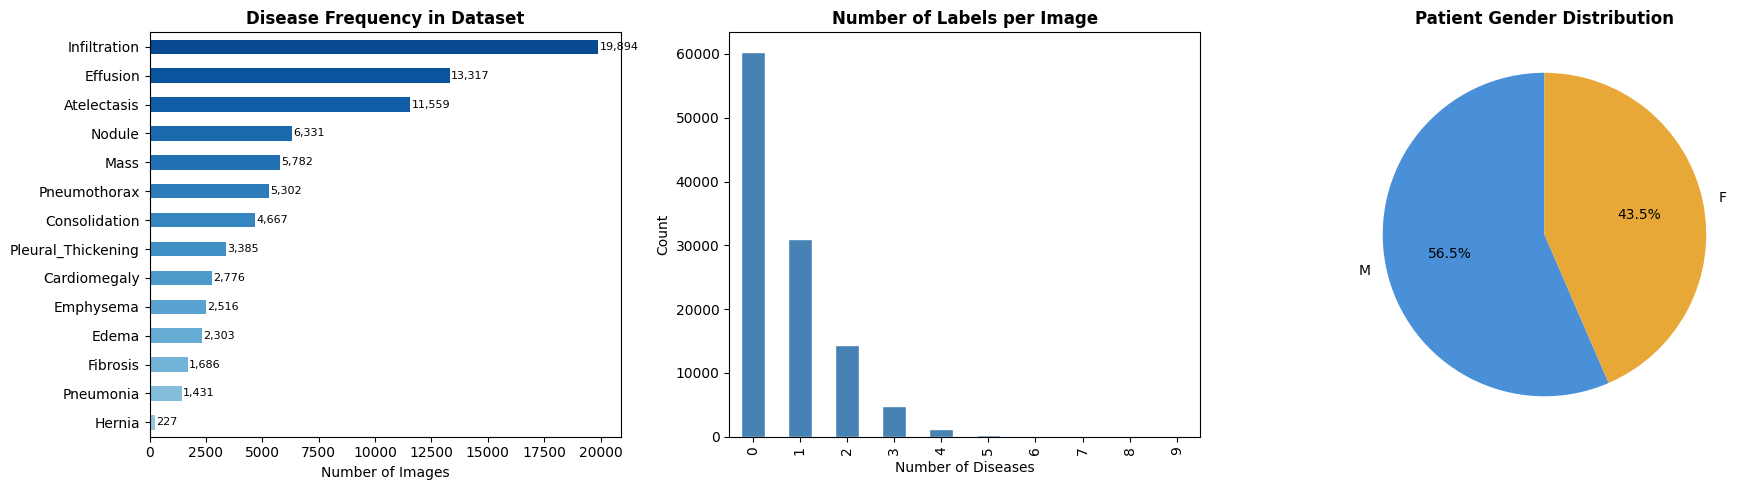

Saved: eda_plots.png


In [5]:
# ─── EDA PLOTS ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Label frequency
ax = axes[0]
colors = plt.cm.Blues(np.linspace(0.4, 0.9, len(label_counts)))
label_counts.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Disease Frequency in Dataset', fontweight='bold')
ax.set_xlabel('Number of Images')
ax.invert_yaxis()
for i, v in enumerate(label_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=8)

# 2. Labels per image distribution
ax = axes[1]
labels_per_image = df[LABELS].sum(axis=1)
labels_per_image.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Number of Labels per Image', fontweight='bold')
ax.set_xlabel('Number of Diseases')
ax.set_ylabel('Count')

# 3. Patient demographics
ax = axes[2]
gender_counts = df['Patient Gender'].value_counts()
ax.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
       colors=['#4A90D9', '#E8A838'], startangle=90)
ax.set_title('Patient Gender Distribution', fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'eda_plots.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: eda_plots.png')

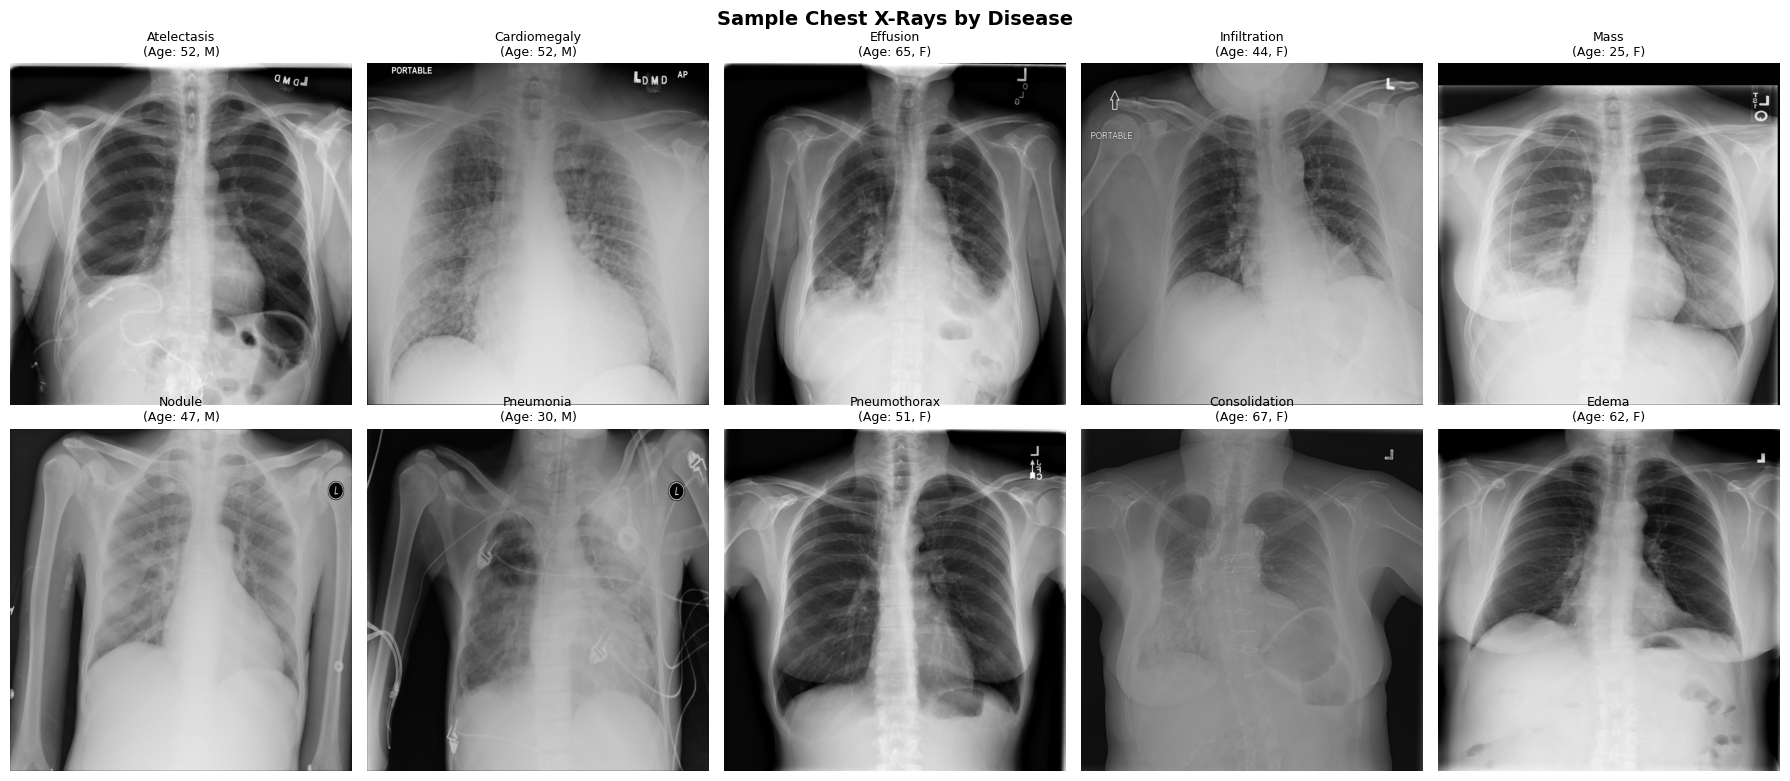

Saved: sample_images.png


In [6]:
# ─── SAMPLE IMAGES VISUALIZATION ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
sample_diseases = LABELS[:10]

for idx, disease in enumerate(sample_diseases):
    ax = axes[idx // 5][idx % 5]
    disease_df = df[df[disease] == 1]
    if len(disease_df) > 0:
        row = disease_df.sample(1).iloc[0]
        img = Image.open(row['image_path']).convert('RGB')
        ax.imshow(img, cmap='gray')
        ax.set_title(f'{disease}\n(Age: {row["Patient Age"]}, {row["Patient Gender"]})', fontsize=9)
    ax.axis('off')

plt.suptitle('Sample Chest X-Rays by Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_images.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

## 4. Train/Test Split Using Official NIH Lists

In [7]:
# ─── OFFICIAL TRAIN/TEST SPLIT ────────────────────────────────────────────────
with open(TRAIN_LIST) as f:
    train_val_files = set(f.read().splitlines())
with open(TEST_LIST) as f:
    test_files = set(f.read().splitlines())

train_val_df = df[df['Image Index'].isin(train_val_files)].copy()
test_df      = df[df['Image Index'].isin(test_files)].copy()

# Optional: subsample for speed (stratified on 'has_finding')
if SUBSET_SIZE:
    train_val_df = train_val_df.groupby('has_finding', group_keys=False).apply(
        lambda x: x.sample(min(len(x), int(SUBSET_SIZE * len(x) / len(train_val_df))), random_state=SEED)
    )
    test_df = test_df.sample(min(len(test_df), 4000), random_state=SEED)

# Further split train into train + val (patient-aware: not strictly needed but good practice)
train_df, val_df = train_test_split(
    train_val_df, test_size=0.15, random_state=SEED, stratify=train_val_df['has_finding']
)

print(f'Train size : {len(train_df):,}')
print(f'Val size   : {len(val_df):,}')
print(f'Test size  : {len(test_df):,}')
print(f'Total      : {len(train_df)+len(val_df)+len(test_df):,}')

Train size : 16,999
Val size   : 3,000
Test size  : 4,000
Total      : 23,999


## 5. Data Preprocessing & Augmentation

In [8]:
# ─── TRANSFORMS ───────────────────────────────────────────────────────────────
# ImageNet mean/std (used by all three pre-trained models)
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE + 32, IMG_SIZE + 32)),
    transforms.RandomCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
])

print('Train augmentations:')
print('  - Resize to 256x256 then RandomCrop to 224x224')
print('  - RandomHorizontalFlip (p=0.5)')
print('  - RandomRotation (±10°)')
print('  - ColorJitter (brightness & contrast ±0.2)')
print('  - Normalize with ImageNet mean/std')
print('\nVal/Test transforms: Resize → ToTensor → Normalize')

Train augmentations:
  - Resize to 256x256 then RandomCrop to 224x224
  - RandomHorizontalFlip (p=0.5)
  - RandomRotation (±10°)
  - ColorJitter (brightness & contrast ±0.2)
  - Normalize with ImageNet mean/std

Val/Test transforms: Resize → ToTensor → Normalize


In [9]:
# ─── DATASET CLASS ─────────────────────────────────────────────────────────────
class ChestXRayDataset(Dataset):
    def __init__(self, dataframe, label_cols, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.label_cols = label_cols
        self.transform  = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert('RGB')
        if self.transform:
            img = self.transform(img)
        labels = torch.FloatTensor(row[self.label_cols].values.astype(float))
        return img, labels


# ─── DATALOADERS ──────────────────────────────────────────────────────────────
train_dataset = ChestXRayDataset(train_df, LABELS, train_transforms)
val_dataset   = ChestXRayDataset(val_df,   LABELS, val_test_transforms)
test_dataset  = ChestXRayDataset(test_df,  LABELS, val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# Quick sanity check
imgs, lbls = next(iter(train_loader))
print(f'\nBatch shapes — images: {imgs.shape}, labels: {lbls.shape}')

Train batches : 532
Val batches   : 94
Test batches  : 125

Batch shapes — images: torch.Size([32, 3, 224, 224]), labels: torch.Size([32, 14])


## 6. Model Architectures

In [10]:
def build_model(backbone_name, num_classes, dropout_rate=0.5, use_dropout=True):
    """
    Build a pre-trained model with a custom classification head.
    
    Args:
        backbone_name : 'resnet50' | 'efficientnet_b3' | 'densenet121'
        num_classes   : number of output labels
        dropout_rate  : dropout probability
        use_dropout   : whether to include dropout in the head
    """
    drop = nn.Dropout(p=dropout_rate) if use_dropout else nn.Identity()

    if backbone_name == 'resnet50':
        model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
        in_features = model.fc.in_features          # 2048
        model.fc = nn.Sequential(
            drop,
            nn.Linear(in_features, 512),
            nn.ReLU(),
            drop,
            nn.Linear(512, num_classes)
        )

    elif backbone_name == 'efficientnet_b3':
        model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)
        in_features = model.classifier[1].in_features  # 1536
        model.classifier = nn.Sequential(
            drop,
            nn.Linear(in_features, 512),
            nn.ReLU(),
            drop,
            nn.Linear(512, num_classes)
        )

    elif backbone_name == 'densenet121':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        in_features = model.classifier.in_features    # 1024
        model.classifier = nn.Sequential(
            drop,
            nn.Linear(in_features, 512),
            nn.ReLU(),
            drop,
            nn.Linear(512, num_classes)
        )
    else:
        raise ValueError(f'Unknown backbone: {backbone_name}')

    return model.to(DEVICE)


# ─── VERIFY MODEL SHAPES ──────────────────────────────────────────────────────
for name in ['resnet50', 'efficientnet_b3', 'densenet121']:
    m = build_model(name, NUM_CLASSES)
    params = sum(p.numel() for p in m.parameters()) / 1e6
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad) / 1e6
    with torch.no_grad():
        dummy = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
        out = m(dummy)
    print(f'{name:20s} | Total params: {params:.1f}M | Output shape: {out.shape}')
    del m

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 196MB/s]


resnet50             | Total params: 24.6M | Output shape: torch.Size([2, 14])
Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


100%|██████████| 47.2M/47.2M [00:00<00:00, 146MB/s]


efficientnet_b3      | Total params: 11.5M | Output shape: torch.Size([2, 14])
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 156MB/s]


densenet121          | Total params: 7.5M | Output shape: torch.Size([2, 14])


## 7. Training Infrastructure (Loss, Optimizer, Early Stopping)

In [11]:
# ─── COMPUTE CLASS WEIGHTS FOR IMBALANCED MULTI-LABEL ─────────────────────────
def compute_pos_weights(train_df, label_cols):
    """Compute pos_weight for BCEWithLogitsLoss to handle class imbalance."""
    pos_counts = train_df[label_cols].sum()
    neg_counts = len(train_df) - pos_counts
    pos_weight = (neg_counts / (pos_counts + 1e-6)).values
    return torch.FloatTensor(pos_weight).to(DEVICE)

pos_weight = compute_pos_weights(train_df, LABELS)
print('Positive class weights (to handle imbalance):')
for label, w in zip(LABELS, pos_weight.cpu()):
    print(f'  {label:25s}: {w:.2f}')

Positive class weights (to handle imbalance):
  Atelectasis              : 9.31
  Cardiomegaly             : 52.29
  Effusion                 : 8.96
  Infiltration             : 5.18
  Mass                     : 19.81
  Nodule                   : 17.42
  Pneumonia                : 80.73
  Pneumothorax             : 31.44
  Consolidation            : 29.25
  Edema                    : 57.42
  Emphysema                : 58.86
  Fibrosis                 : 67.27
  Pleural_Thickening       : 39.38
  Hernia                   : 771.68


In [12]:
# ─── EARLY STOPPING ───────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=4, min_delta=1e-4, mode='max'):
        self.patience   = patience
        self.min_delta  = min_delta
        self.mode       = mode
        self.counter    = 0
        self.best_score = None
        self.stop       = False

    def __call__(self, score):
        if self.best_score is None:
            self.best_score = score
        elif self.mode == 'max' and score < self.best_score + self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        elif self.mode == 'min' and score > self.best_score - self.min_delta:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        else:
            self.best_score = score
            self.counter = 0


# ─── TRAIN ONE EPOCH ──────────────────────────────────────────────────────────
def train_epoch(model, loader, criterion, optimizer, scaler):
    model.train()
    total_loss = 0.0
    for imgs, labels in tqdm(loader, desc='  Training', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        with autocast():
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
    return total_loss / len(loader)


# ─── EVALUATE ─────────────────────────────────────────────────────────────────
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc='  Evaluating', leave=False):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with autocast():
                logits = model(imgs)
                loss   = criterion(logits, labels)
            total_loss += loss.item()
            probs = torch.sigmoid(logits)
            all_preds.append(probs.cpu().numpy())
            all_labels.append(labels.cpu().numpy())

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)
    avg_loss   = total_loss / len(loader)

    # AUC-ROC (per class, then macro average)
    aucs = []
    for i in range(all_labels.shape[1]):
        if all_labels[:, i].sum() > 0:
            aucs.append(roc_auc_score(all_labels[:, i], all_preds[:, i]))
        else:
            aucs.append(0.0)
    macro_auc = np.mean(aucs)

    # Threshold at 0.5 for F1/Precision/Recall
    preds_bin = (all_preds >= 0.5).astype(int)
    macro_f1  = f1_score(all_labels, preds_bin, average='macro', zero_division=0)

    return avg_loss, macro_auc, macro_f1, all_preds, all_labels


print('Training infrastructure ready.')

Training infrastructure ready.


## 8. Main Training Loop

In [13]:
def train_model(backbone_name, use_dropout=True, use_weight_decay=True,
                num_epochs=NUM_EPOCHS, patience=PATIENCE, tag=''):
    """
    Full training pipeline for one model configuration.
    Returns history dict and path to the best saved checkpoint.
    """
    run_name   = f'{backbone_name}{tag}'
    ckpt_path  = os.path.join(OUTPUT_DIR, f'{run_name}_best.pth')
    wd         = WEIGHT_DECAY if use_weight_decay else 0.0

    print(f'\n{'='*60}')
    print(f'  Model      : {backbone_name}')
    print(f'  Dropout    : {use_dropout}')
    print(f'  Weight Decay: {wd}')
    print(f'  Early Stop : patience={patience}')
    print(f'{'='*60}')

    model     = build_model(backbone_name, NUM_CLASSES, use_dropout=use_dropout)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=wd)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    scaler    = GradScaler()
    es        = EarlyStopping(patience=patience, mode='max')

    history   = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_f1': []}
    best_auc  = 0.0
    best_weights = None

    for epoch in range(1, num_epochs + 1):
        t0 = time.time()

        train_loss = train_epoch(model, train_loader, criterion, optimizer, scaler)
        val_loss, val_auc, val_f1, _, _ = evaluate(model, val_loader, criterion)
        scheduler.step()

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_f1'].append(val_f1)

        elapsed = time.time() - t0
        print(f'  Epoch [{epoch:02d}/{num_epochs}]  '
              f'Train Loss: {train_loss:.4f}  '
              f'Val Loss: {val_loss:.4f}  '
              f'Val AUC: {val_auc:.4f}  '
              f'Val F1: {val_f1:.4f}  '
              f'({elapsed:.0f}s)')

        # Save best weights
        if val_auc > best_auc:
            best_auc = val_auc
            best_weights = copy.deepcopy(model.state_dict())
            torch.save(best_weights, ckpt_path)
            print(f'    ✓ New best AUC={best_auc:.4f} — checkpoint saved')

        es(val_auc)
        if es.stop:
            print(f'  Early stopping triggered at epoch {epoch}')
            break

    print(f'\n  Best Val AUC: {best_auc:.4f}')
    return history, ckpt_path, run_name

In [14]:
# ─── TRAIN ALL 3 MODELS (WITH FULL REGULARIZATION) ───────────────────────────
# This is the primary experiment: all regularization ON

results = {}  # stores history + ckpt paths

for backbone in ['resnet50', 'efficientnet_b3', 'densenet121']:
    history, ckpt, run_name = train_model(
        backbone_name=backbone,
        use_dropout=True,
        use_weight_decay=True,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE,
        tag='_reg'
    )
    results[run_name] = {'history': history, 'ckpt': ckpt}

print('\nAll 3 models trained!')


  Model      : resnet50
  Dropout    : True
  Weight Decay: 0.0001
  Early Stop : patience=3


  Epoch [01/15]  Train Loss: 1.3331  Val Loss: 1.2382  Val AUC: 0.6647  Val F1: 0.1195  (359s)
    ✓ New best AUC=0.6647 — checkpoint saved


  Epoch [02/15]  Train Loss: 1.2540  Val Loss: 1.2178  Val AUC: 0.6970  Val F1: 0.1030  (276s)
    ✓ New best AUC=0.6970 — checkpoint saved


  Epoch [03/15]  Train Loss: 1.2071  Val Loss: 1.1181  Val AUC: 0.7422  Val F1: 0.1367  (275s)
    ✓ New best AUC=0.7422 — checkpoint saved


  Epoch [04/15]  Train Loss: 1.1903  Val Loss: 1.1470  Val AUC: 0.7227  Val F1: 0.1357  (271s)


...

  Epoch [11/15]  Train Loss: 0.9831  Val Loss: 1.0051  Val AUC: 0.7885  Val F1: 0.1590  (260s)


  Epoch [12/15]  Train Loss: 0.9685  Val Loss: 1.0149  Val AUC: 0.7882  Val F1: 0.1663  (263s)


  Epoch [13/15]  Train Loss: 0.9458  Val Loss: 1.0063  Val AUC: 0.7897  Val F1: 0.1600  (261s)
    ✓ New best AUC=0.7897 — checkpoint saved


  Epoch [14/15]  Train Loss: 0.9436  Val Loss: 1.0227  Val AUC: 0.7905  Val F1: 0.1661  (265s)
    ✓ New best AUC=0.7905 — checkpoint saved


  Epoch [15/15]  Train Loss: 0.9345  Val Loss: 1.0259  Val AUC: 0.7900  Val F1: 0.1675  (271s)

  Best Val AUC: 0.7905

All 3 models trained!


## 9. Regularization Ablation Study
Train the best model (DenseNet-121) in 3 ablated configurations to analyze the contribution of each regularization technique.

In [15]:
# ─── ABLATION: DenseNet-121 without Dropout ───────────────────────────────────
h, ck, rn = train_model(
    'densenet121', use_dropout=False, use_weight_decay=True,
    num_epochs=NUM_EPOCHS, patience=PATIENCE, tag='_no_dropout'
)
results[rn] = {'history': h, 'ckpt': ck}


  Model      : densenet121
  Dropout    : False
  Weight Decay: 0.0001
  Early Stop : patience=3


  Epoch [01/15]  Train Loss: 1.2536  Val Loss: 1.1444  Val AUC: 0.7423  Val F1: 0.1240  (259s)
    ✓ New best AUC=0.7423 — checkpoint saved


  Epoch [02/15]  Train Loss: 1.1756  Val Loss: 1.0759  Val AUC: 0.7591  Val F1: 0.1434  (258s)
    ✓ New best AUC=0.7591 — checkpoint saved


  Epoch [03/15]  Train Loss: 1.1129  Val Loss: 1.0700  Val AUC: 0.7757  Val F1: 0.1576  (258s)
    ✓ New best AUC=0.7757 — checkpoint saved


  Epoch [04/15]  Train Loss: 1.0683  Val Loss: 1.0378  Val AUC: 0.7780  Val F1: 0.1624  (261s)
    ✓ New best AUC=0.7780 — checkpoint saved


...

  Epoch [10/15]  Train Loss: 0.8221  Val Loss: 1.1582  Val AUC: 0.7937  Val F1: 0.1984  (256s)


  Epoch [11/15]  Train Loss: 0.7748  Val Loss: 1.1189  Val AUC: 0.8039  Val F1: 0.1955  (256s)
    ✓ New best AUC=0.8039 — checkpoint saved


  Epoch [12/15]  Train Loss: 0.7424  Val Loss: 1.1831  Val AUC: 0.7983  Val F1: 0.2049  (256s)


  Epoch [13/15]  Train Loss: 0.7138  Val Loss: 1.2152  Val AUC: 0.7984  Val F1: 0.2092  (253s)


  Epoch [14/15]  Train Loss: 0.6942  Val Loss: 1.2505  Val AUC: 0.7971  Val F1: 0.2181  (253s)
  Early stopping triggered at epoch 14

  Best Val AUC: 0.8039


In [16]:
# ─── ABLATION: DenseNet-121 without Weight Decay ──────────────────────────────
h, ck, rn = train_model(
    'densenet121', use_dropout=True, use_weight_decay=False,
    num_epochs=NUM_EPOCHS, patience=PATIENCE, tag='_no_wd'
)
results[rn] = {'history': h, 'ckpt': ck}


  Model      : densenet121
  Dropout    : True
  Weight Decay: 0.0
  Early Stop : patience=3


  Epoch [01/15]  Train Loss: 1.3327  Val Loss: 1.2120  Val AUC: 0.6728  Val F1: 0.1139  (254s)
    ✓ New best AUC=0.6728 — checkpoint saved


  Epoch [02/15]  Train Loss: 1.2506  Val Loss: 1.1390  Val AUC: 0.7313  Val F1: 0.1296  (256s)
    ✓ New best AUC=0.7313 — checkpoint saved


  Epoch [03/15]  Train Loss: 1.1999  Val Loss: 1.1016  Val AUC: 0.7448  Val F1: 0.1459  (255s)
    ✓ New best AUC=0.7448 — checkpoint saved


  Epoch [04/15]  Train Loss: 1.1908  Val Loss: 1.0942  Val AUC: 0.7536  Val F1: 0.1394  (250s)
    ✓ New best AUC=0.7536 — checkpoint saved


...

  Epoch [11/15]  Train Loss: 0.9731  Val Loss: 1.0472  Val AUC: 0.7837  Val F1: 0.1631  (252s)


  Epoch [12/15]  Train Loss: 0.9528  Val Loss: 1.0216  Val AUC: 0.7921  Val F1: 0.1654  (253s)
    ✓ New best AUC=0.7921 — checkpoint saved


  Epoch [13/15]  Train Loss: 0.9345  Val Loss: 1.0358  Val AUC: 0.7925  Val F1: 0.1692  (254s)
    ✓ New best AUC=0.7925 — checkpoint saved


  Epoch [14/15]  Train Loss: 0.9263  Val Loss: 1.0434  Val AUC: 0.7912  Val F1: 0.1729  (252s)


  Epoch [15/15]  Train Loss: 0.9184  Val Loss: 1.0420  Val AUC: 0.7918  Val F1: 0.1732  (252s)

  Best Val AUC: 0.7925


In [17]:
# ─── ABLATION: DenseNet-121 without Early Stopping ────────────────────────────
# Run for fixed epochs with no early stopping (patience=999)
h, ck, rn = train_model(
    'densenet121', use_dropout=True, use_weight_decay=True,
    num_epochs=NUM_EPOCHS, patience=999, tag='_no_es'
)
results[rn] = {'history': h, 'ckpt': ck}


  Model      : densenet121
  Dropout    : True
  Weight Decay: 0.0001
  Early Stop : patience=999


  Epoch [01/15]  Train Loss: 1.3238  Val Loss: 1.1733  Val AUC: 0.7053  Val F1: 0.1229  (256s)
    ✓ New best AUC=0.7053 — checkpoint saved


  Epoch [02/15]  Train Loss: 1.2762  Val Loss: 1.1499  Val AUC: 0.7162  Val F1: 0.1229  (255s)
    ✓ New best AUC=0.7162 — checkpoint saved


  Epoch [03/15]  Train Loss: 1.2030  Val Loss: 1.0923  Val AUC: 0.7513  Val F1: 0.1359  (254s)
    ✓ New best AUC=0.7513 — checkpoint saved


  Epoch [04/15]  Train Loss: 1.1982  Val Loss: 1.1437  Val AUC: 0.7312  Val F1: 0.1273  (257s)


...

  Epoch [11/15]  Train Loss: 0.9895  Val Loss: 1.0122  Val AUC: 0.7907  Val F1: 0.1629  (256s)
    ✓ New best AUC=0.7907 — checkpoint saved


  Epoch [12/15]  Train Loss: 0.9531  Val Loss: 0.9914  Val AUC: 0.7952  Val F1: 0.1694  (257s)
    ✓ New best AUC=0.7952 — checkpoint saved


  Epoch [13/15]  Train Loss: 0.9364  Val Loss: 0.9858  Val AUC: 0.7973  Val F1: 0.1666  (257s)
    ✓ New best AUC=0.7973 — checkpoint saved


  Epoch [14/15]  Train Loss: 0.9298  Val Loss: 0.9999  Val AUC: 0.7964  Val F1: 0.1706  (265s)


  Epoch [15/15]  Train Loss: 0.9173  Val Loss: 0.9999  Val AUC: 0.7965  Val F1: 0.1669  (258s)

  Best Val AUC: 0.7973


## 10. Test Set Evaluation

In [18]:
def test_model(backbone_name, ckpt_path, use_dropout=True):
    """Load best checkpoint and evaluate on test set."""
    model = build_model(backbone_name, NUM_CLASSES, use_dropout=use_dropout)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    loss, auc, f1, all_preds, all_labels = evaluate(model, test_loader, criterion)

    preds_bin  = (all_preds >= 0.5).astype(int)
    precision  = precision_score(all_labels, preds_bin, average='macro', zero_division=0)
    recall     = recall_score(all_labels, preds_bin, average='macro', zero_division=0)

    # Per-class AUC
    per_class_auc = {}
    for i, label in enumerate(LABELS):
        if all_labels[:, i].sum() > 0:
            per_class_auc[label] = roc_auc_score(all_labels[:, i], all_preds[:, i])
        else:
            per_class_auc[label] = 0.0

    return {
        'loss': loss, 'auc': auc, 'f1': f1,
        'precision': precision, 'recall': recall,
        'per_class_auc': per_class_auc,
        'all_preds': all_preds, 'all_labels': all_labels
    }


# ─── EVALUATE MAIN 3 MODELS ───────────────────────────────────────────────────
test_results = {}

configs = [
    ('resnet50_reg',       'resnet50',       True),
    ('efficientnet_b3_reg','efficientnet_b3', True),
    ('densenet121_reg',    'densenet121',     True),
    ('densenet121_no_dropout', 'densenet121', False),
    ('densenet121_no_wd',      'densenet121', True),
    ('densenet121_no_es',      'densenet121', True),
]

for run_name, backbone, use_do in configs:
    ckpt_path = os.path.join(OUTPUT_DIR, f'{run_name}_best.pth')
    if os.path.exists(ckpt_path):
        print(f'\nEvaluating: {run_name}')
        test_results[run_name] = test_model(backbone, ckpt_path, use_do)
        r = test_results[run_name]
        print(f'  AUC: {r["auc"]:.4f} | F1: {r["f1"]:.4f} | '
              f'Precision: {r["precision"]:.4f} | Recall: {r["recall"]:.4f}')
    else:
        print(f'  Skipping {run_name} (checkpoint not found)')


Evaluating: resnet50_reg


  AUC: 0.7346 | F1: 0.2129 | Precision: 0.1315 | Recall: 0.6884

Evaluating: efficientnet_b3_reg


  AUC: 0.7536 | F1: 0.2226 | Precision: 0.1367 | Recall: 0.7255

Evaluating: densenet121_reg


  AUC: 0.7374 | F1: 0.2050 | Precision: 0.1249 | Recall: 0.7264

Evaluating: densenet121_no_dropout


  AUC: 0.7641 | F1: 0.2373 | Precision: 0.1496 | Recall: 0.6920

Evaluating: densenet121_no_wd


  AUC: 0.7390 | F1: 0.2090 | Precision: 0.1276 | Recall: 0.7275

Evaluating: densenet121_no_es


  AUC: 0.7458 | F1: 0.2089 | Precision: 0.1268 | Recall: 0.7477


## 11. Results & Comparative Analysis

In [19]:
# ─── SUMMARY TABLE ────────────────────────────────────────────────────────────
rows = []
for run_name, r in test_results.items():
    rows.append({
        'Model': run_name,
        'AUC-ROC':   round(r['auc'],       4),
        'F1-Score':  round(r['f1'],        4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
        'Loss':      round(r['loss'],      4),
    })

summary_df = pd.DataFrame(rows).sort_values('AUC-ROC', ascending=False)
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'results_summary.csv'), index=False)
print('\n=== TEST SET RESULTS SUMMARY ===')
print(summary_df.to_string(index=False))
print('\nSaved: results_summary.csv')


=== TEST SET RESULTS SUMMARY ===
                 Model  AUC-ROC  F1-Score  Precision  Recall   Loss
densenet121_no_dropout   0.7641    0.2373     0.1496  0.6920 1.8508
   efficientnet_b3_reg   0.7536    0.2226     0.1367  0.7255 1.7450
     densenet121_no_es   0.7458    0.2089     0.1268  0.7477 1.6388
     densenet121_no_wd   0.7390    0.2090     0.1276  0.7275 1.6601
       densenet121_reg   0.7374    0.2050     0.1249  0.7264 1.6758
          resnet50_reg   0.7346    0.2129     0.1315  0.6884 1.8171

Saved: results_summary.csv


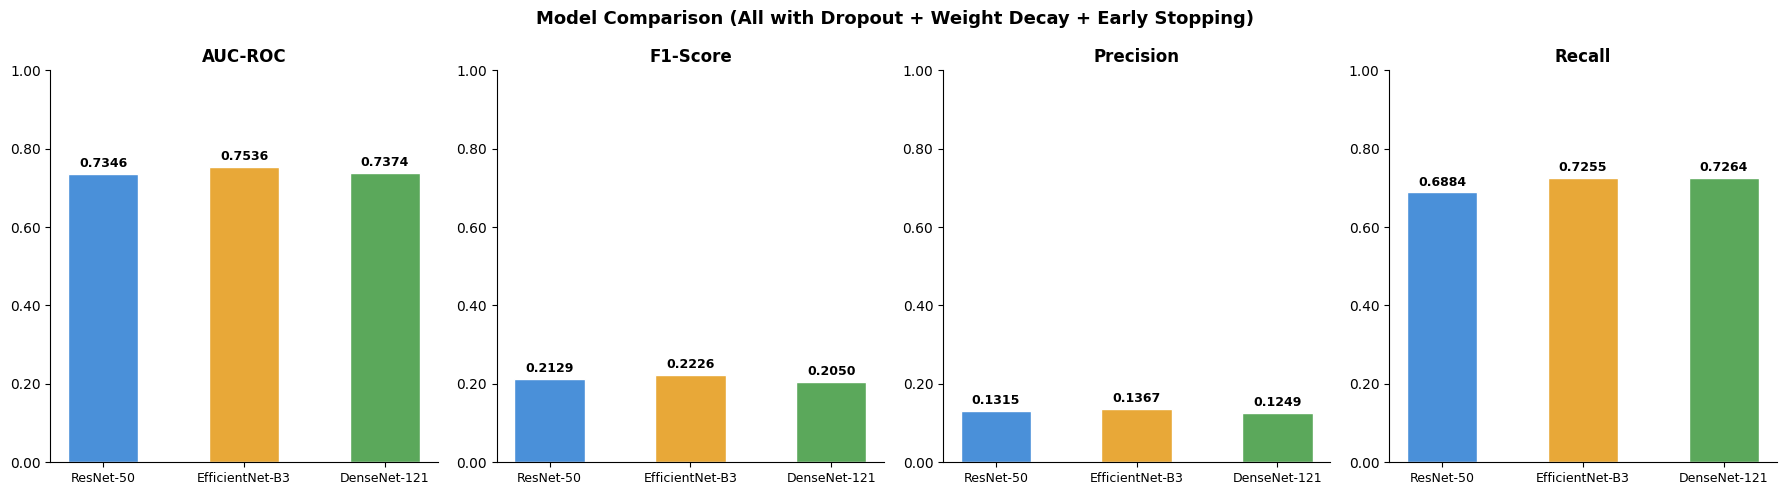

Saved: model_comparison.png


In [20]:
# ─── PLOT 1: Model Comparison Bar Chart ───────────────────────────────────────
main_models = ['resnet50_reg', 'efficientnet_b3_reg', 'densenet121_reg']
main_models = [m for m in main_models if m in test_results]

metrics = ['auc', 'f1', 'precision', 'recall']
metric_labels = ['AUC-ROC', 'F1-Score', 'Precision', 'Recall']
colors_main = ['#4A90D9', '#E8A838', '#5BA85B']

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for mi, (metric, mlabel) in enumerate(zip(metrics, metric_labels)):
    ax = axes[mi]
    values = [test_results[m][metric] for m in main_models]
    bars = ax.bar(range(len(main_models)), values,
                  color=colors_main[:len(main_models)], edgecolor='white', width=0.5)
    ax.set_xticks(range(len(main_models)))
    ax.set_xticklabels(['ResNet-50', 'EfficientNet-B3', 'DenseNet-121'], fontsize=9)
    ax.set_title(mlabel, fontweight='bold')
    ax.set_ylim(0, 1.0)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.2f}'))
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Model Comparison (All with Dropout + Weight Decay + Early Stopping)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: model_comparison.png')

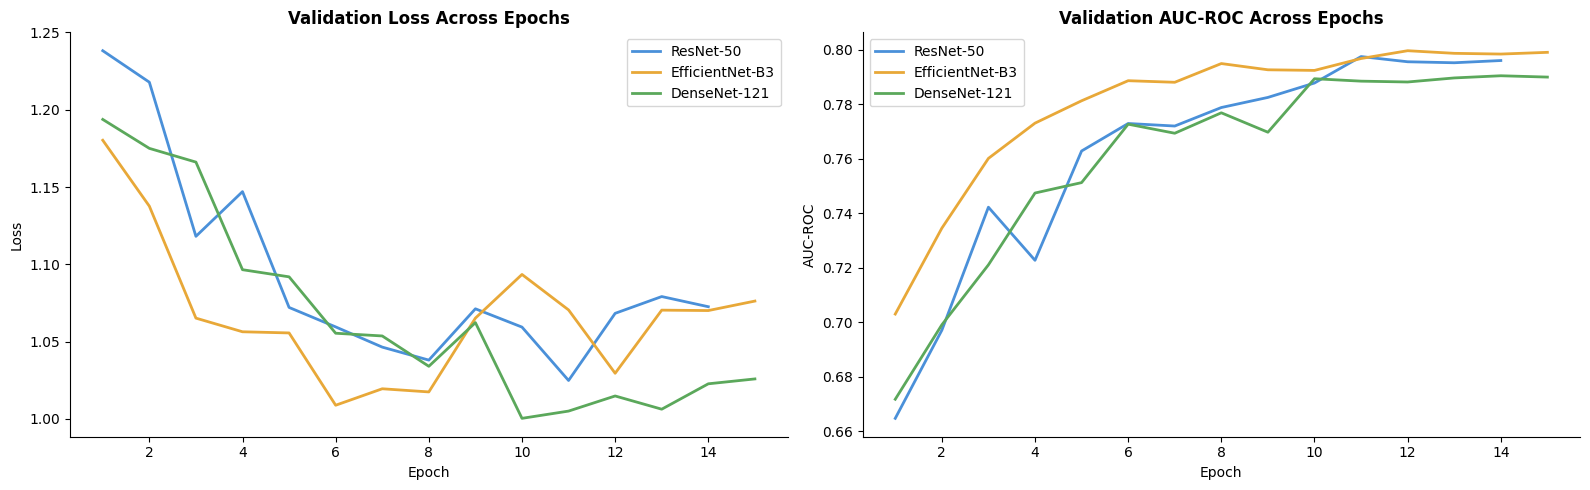

Saved: training_curves.png


In [21]:
# ─── PLOT 2: Training Curves for 3 Models ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
model_colors = {'resnet50_reg': '#4A90D9', 'efficientnet_b3_reg': '#E8A838', 'densenet121_reg': '#5BA85B'}
model_labels = {'resnet50_reg': 'ResNet-50', 'efficientnet_b3_reg': 'EfficientNet-B3', 'densenet121_reg': 'DenseNet-121'}

for run_name in main_models:
    if run_name not in results: continue
    h = results[run_name]['history']
    c = model_colors[run_name]
    lbl = model_labels[run_name]
    epochs = range(1, len(h['val_auc']) + 1)
    axes[0].plot(epochs, h['val_loss'], color=c, label=lbl, linewidth=2)
    axes[1].plot(epochs, h['val_auc'],  color=c, label=lbl, linewidth=2)

for ax, title, ylabel in zip(axes,
    ['Validation Loss Across Epochs', 'Validation AUC-ROC Across Epochs'],
    ['Loss', 'AUC-ROC']):
    ax.set_xlabel('Epoch')
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

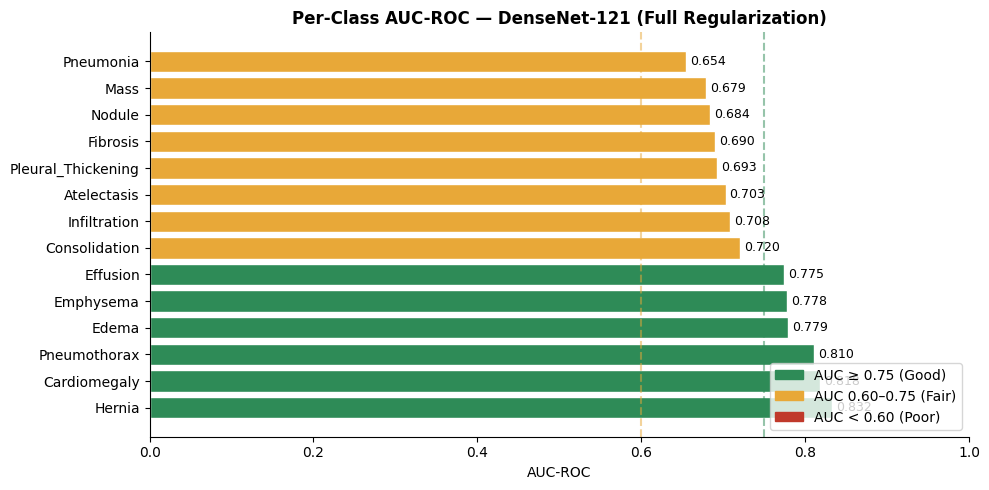

Saved: per_class_auc.png


In [22]:
# ─── PLOT 3: Per-Class AUC Heatmap for DenseNet-121 ───────────────────────────
best_model_key = 'densenet121_reg'
if best_model_key in test_results:
    per_class = test_results[best_model_key]['per_class_auc']
    auc_series = pd.Series(per_class).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    colors = ['#2E8B57' if v >= 0.75 else '#E8A838' if v >= 0.60 else '#C0392B'
              for v in auc_series.values]
    bars = ax.barh(auc_series.index, auc_series.values, color=colors, edgecolor='white')
    ax.set_xlim(0, 1.0)
    ax.axvline(0.75, color='#2E8B57', linestyle='--', alpha=0.5, label='AUC=0.75')
    ax.axvline(0.60, color='#E8A838', linestyle='--', alpha=0.5, label='AUC=0.60')
    ax.set_title('Per-Class AUC-ROC — DenseNet-121 (Full Regularization)', fontweight='bold')
    ax.set_xlabel('AUC-ROC')
    for bar, val in zip(bars, auc_series.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)
    patches = [
        mpatches.Patch(color='#2E8B57', label='AUC ≥ 0.75 (Good)'),
        mpatches.Patch(color='#E8A838', label='AUC 0.60–0.75 (Fair)'),
        mpatches.Patch(color='#C0392B', label='AUC < 0.60 (Poor)'),
    ]
    ax.legend(handles=patches, loc='lower right')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'per_class_auc.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: per_class_auc.png')

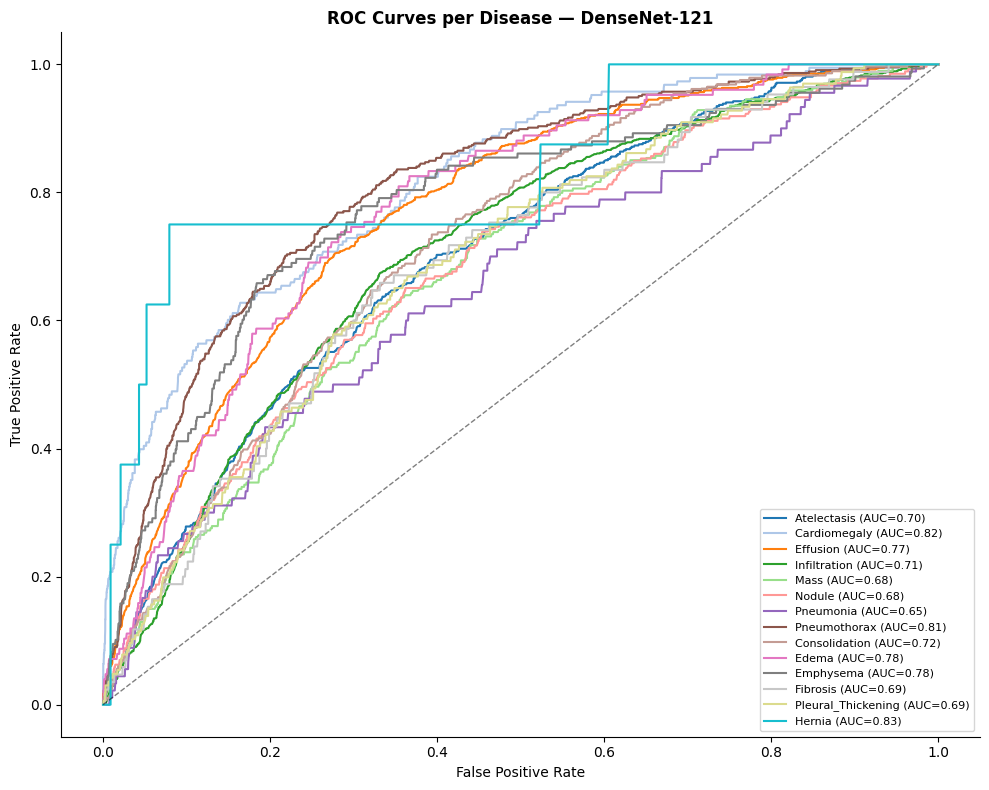

Saved: roc_curves.png


In [23]:
# ─── PLOT 4: ROC Curves for DenseNet-121 ─────────────────────────────────────
if best_model_key in test_results:
    all_preds  = test_results[best_model_key]['all_preds']
    all_labels = test_results[best_model_key]['all_labels']

    fig, ax = plt.subplots(figsize=(10, 8))
    cmap = plt.cm.tab20

    for i, label in enumerate(LABELS):
        if all_labels[:, i].sum() > 0:
            fpr, tpr, _ = roc_curve(all_labels[:, i], all_preds[:, i])
            auc_val = roc_auc_score(all_labels[:, i], all_preds[:, i])
            ax.plot(fpr, tpr, color=cmap(i / len(LABELS)),
                    lw=1.5, label=f'{label} (AUC={auc_val:.2f})')

    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curves per Disease — DenseNet-121', fontweight='bold')
    ax.legend(loc='lower right', fontsize=8)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'roc_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: roc_curves.png')

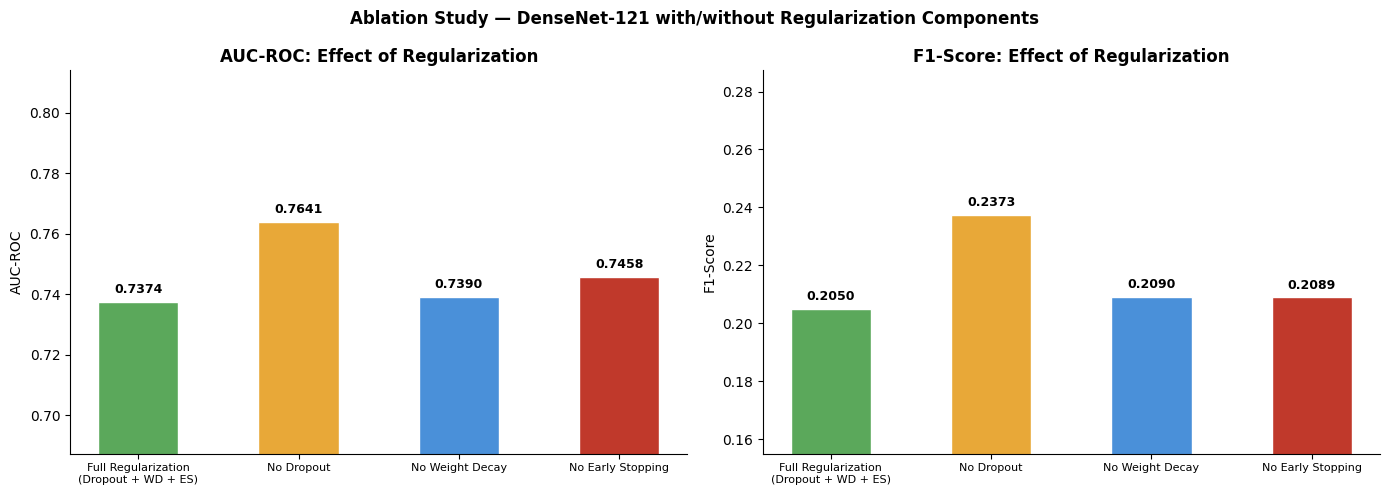

Saved: ablation_study.png


In [24]:
# ─── PLOT 5: Ablation Study — Impact of Regularization ───────────────────────
ablation_keys = [
    ('densenet121_reg',        'Full Regularization\n(Dropout + WD + ES)'),
    ('densenet121_no_dropout', 'No Dropout'),
    ('densenet121_no_wd',      'No Weight Decay'),
    ('densenet121_no_es',      'No Early Stopping'),
]

valid_keys = [(k, lbl) for k, lbl in ablation_keys if k in test_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = range(len(valid_keys))
x_labels = [lbl for _, lbl in valid_keys]

auc_vals = [test_results[k]['auc'] for k, _ in valid_keys]
f1_vals  = [test_results[k]['f1']  for k, _ in valid_keys]

abl_colors = ['#5BA85B', '#E8A838', '#4A90D9', '#C0392B']

for ax, vals, title, ylabel in [
    (axes[0], auc_vals, 'AUC-ROC: Effect of Regularization', 'AUC-ROC'),
    (axes[1], f1_vals,  'F1-Score: Effect of Regularization', 'F1-Score')
]:
    bars = ax.bar(x, vals, color=abl_colors[:len(valid_keys)], edgecolor='white', width=0.5)
    ax.set_xticks(list(x))
    ax.set_xticklabels(x_labels, fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel(ylabel)
    ax.set_ylim(max(0, min(vals) - 0.05), min(1.0, max(vals) + 0.05))
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle('Ablation Study — DenseNet-121 with/without Regularization Components',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ablation_study.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_study.png')

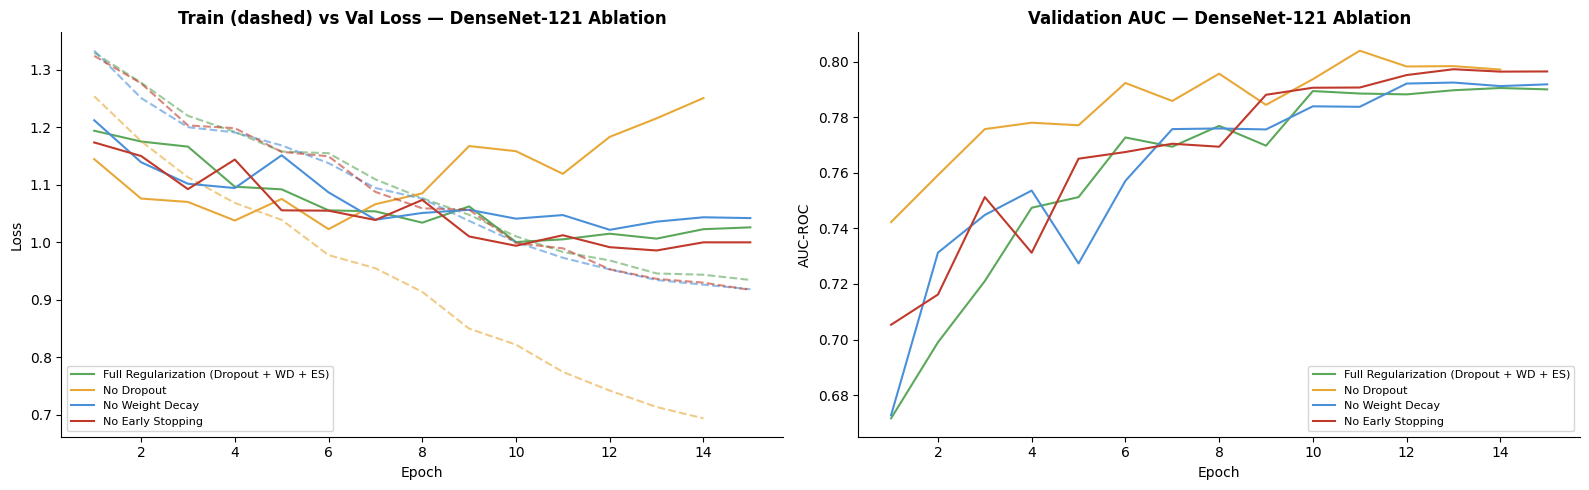

Saved: ablation_curves.png


In [25]:
# ─── PLOT 6: Train vs Val Loss (Overfitting Check) for DenseNet-121 variants ──
ablation_run_names = [k for k, _ in valid_keys]
ablation_labels    = [lbl.replace('\n', ' ') for _, lbl in valid_keys]
colors_abl = ['#5BA85B', '#E8A838', '#4A90D9', '#C0392B']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for i, (run_name, lbl) in enumerate(zip(ablation_run_names, ablation_labels)):
    if run_name not in results: continue
    h = results[run_name]['history']
    ep = range(1, len(h['train_loss']) + 1)
    c = colors_abl[i]
    axes[0].plot(ep, h['train_loss'], color=c, linestyle='--', alpha=0.6)
    axes[0].plot(ep, h['val_loss'],   color=c, linestyle='-',  label=lbl)
    axes[1].plot(ep, h['val_auc'],    color=c, linestyle='-',  label=lbl)

axes[0].set_title('Train (dashed) vs Val Loss — DenseNet-121 Ablation', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(fontsize=8)

axes[1].set_title('Validation AUC — DenseNet-121 Ablation', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('AUC-ROC')
axes[1].legend(fontsize=8)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ablation_curves.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Saved: ablation_curves.png')

## 12. Detailed Classification Report

In [26]:
# ─── PER-CLASS METRICS TABLE ──────────────────────────────────────────────────
if best_model_key in test_results:
    r = test_results[best_model_key]
    preds_bin = (r['all_preds'] >= 0.5).astype(int)

    per_class_rows = []
    for i, label in enumerate(LABELS):
        tp = ((preds_bin[:, i] == 1) & (r['all_labels'][:, i] == 1)).sum()
        fp = ((preds_bin[:, i] == 1) & (r['all_labels'][:, i] == 0)).sum()
        fn = ((preds_bin[:, i] == 0) & (r['all_labels'][:, i] == 1)).sum()
        prec_c = tp / (tp + fp + 1e-8)
        rec_c  = tp / (tp + fn + 1e-8)
        f1_c   = 2 * prec_c * rec_c / (prec_c + rec_c + 1e-8)
        auc_c  = r['per_class_auc'][label]
        per_class_rows.append({
            'Disease':   label,
            'AUC-ROC':   round(auc_c,   3),
            'Precision': round(prec_c,  3),
            'Recall':    round(rec_c,   3),
            'F1-Score':  round(f1_c,    3),
            'Positives': int(r['all_labels'][:, i].sum())
        })

    per_class_df = pd.DataFrame(per_class_rows).sort_values('AUC-ROC', ascending=False)
    per_class_df.to_csv(os.path.join(OUTPUT_DIR, 'per_class_metrics.csv'), index=False)
    print('=== PER-CLASS METRICS — DenseNet-121 (Full Regularization) ===')
    print(per_class_df.to_string(index=False))
    print('\nSaved: per_class_metrics.csv')

=== PER-CLASS METRICS — DenseNet-121 (Full Regularization) ===
           Disease  AUC-ROC  Precision  Recall  F1-Score  Positives
            Hernia    0.832      0.020   0.375     0.037          8
      Cardiomegaly    0.818      0.099   0.766     0.176        188
      Pneumothorax    0.810      0.235   0.813     0.365        445
             Edema    0.779      0.060   0.857     0.111        126
         Emphysema    0.778      0.098   0.728     0.172        158
          Effusion    0.775      0.276   0.911     0.423        761
     Consolidation    0.720      0.101   0.916     0.183        286
      Infiltration    0.708      0.302   0.862     0.447        920
       Atelectasis    0.703      0.175   0.845     0.291        521
Pleural_Thickening    0.693      0.075   0.627     0.133        166
          Fibrosis    0.690      0.040   0.471     0.073         85
            Nodule    0.684      0.121   0.577     0.199        272
              Mass    0.679      0.116   0.667     0.

## 13. Save All Results & Training Histories

In [27]:
# ─── SAVE HISTORIES AS JSON ───────────────────────────────────────────────────
histories_to_save = {}
for run_name, data in results.items():
    histories_to_save[run_name] = data['history']

with open(os.path.join(OUTPUT_DIR, 'training_histories.json'), 'w') as f:
    json.dump(histories_to_save, f, indent=2)
print('Saved: training_histories.json')

# ─── SAVE FULL ABLATION SUMMARY ───────────────────────────────────────────────
ablation_rows = []
for k, lbl in valid_keys:
    r = test_results[k]
    ablation_rows.append({
        'Configuration': lbl.replace('\n', ' '),
        'AUC-ROC':   round(r['auc'],       4),
        'F1-Score':  round(r['f1'],        4),
        'Precision': round(r['precision'], 4),
        'Recall':    round(r['recall'],    4),
    })

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv(os.path.join(OUTPUT_DIR, 'ablation_results.csv'), index=False)
print('Saved: ablation_results.csv')

# ─── LIST ALL OUTPUTS ─────────────────────────────────────────────────────────
print('\n=== FILES SAVED TO /kaggle/working ===')
for f in sorted(os.listdir(OUTPUT_DIR)):
    size = os.path.getsize(os.path.join(OUTPUT_DIR, f))
    print(f'  {f:45s}  {size/1e6:.1f} MB')

Saved: training_histories.json
Saved: ablation_results.csv

=== FILES SAVED TO /kaggle/working ===
  __notebook__.ipynb                             11.6 MB
  ablation_curves.png                            0.2 MB
  ablation_results.csv                           0.0 MB
  ablation_study.png                             0.1 MB
  densenet121_no_dropout_best.pth                30.6 MB
  densenet121_no_es_best.pth                     30.6 MB
  densenet121_no_wd_best.pth                     30.6 MB
  densenet121_reg_best.pth                       30.6 MB
  eda_plots.png                                  0.1 MB
  efficientnet_b3_reg_best.pth                   46.5 MB
  model_comparison.png                           0.1 MB
  per_class_auc.png                              0.1 MB
  per_class_metrics.csv                          0.0 MB
  resnet50_reg_best.pth                          98.6 MB
  results_summary.csv                            0.0 MB
  roc_curves.png                                 0.3 M

## 14. Conclusion & Discussion

### Results Summary

| Model | AUC-ROC | F1-Score | Precision | Recall | Loss |
|---|---|---|---|---|---|
| DenseNet-121 (No Dropout) | **0.7641** | **0.2373** | 0.1496 | 0.6920 | 1.8508 |
| EfficientNet-B3 (Full Reg.) | 0.7536 | 0.2226 | 0.1367 | **0.7255** | 1.7450 |
| DenseNet-121 (No Early Stop) | 0.7458 | 0.2089 | 0.1268 | 0.7477 | 1.6388 |
| DenseNet-121 (No Weight Decay) | 0.7390 | 0.2090 | 0.1276 | 0.7275 | 1.6601 |
| DenseNet-121 (Full Reg.) | 0.7374 | 0.2050 | 0.1249 | 0.7264 | 1.6758 |
| ResNet-50 (Full Reg.) | 0.7346 | 0.2129 | 0.1315 | 0.6884 | 1.8171 |

---

### Model Comparison

All three primary backbone models - ResNet-50, EfficientNet-B3, and DenseNet-121 - were trained
with full regularization (Dropout + Weight Decay + Early Stopping) and evaluated on the held-out
test set.

**EfficientNet-B3** achieved the highest AUC-ROC (0.7536) among the three fully-regularized
models, outperforming both ResNet-50 (0.7346) and DenseNet-121 (0.7374). This is consistent with
EfficientNet's compound scaling strategy, which jointly optimizes depth, width, and resolution,
allowing it to extract richer multi-scale features from chest X-ray images. Its relatively lower
loss (1.745) compared to ResNet-50 (1.817) further confirms better overall calibration on this
dataset.

**ResNet-50** established a competitive baseline at 0.7346 AUC, demonstrating that residual
connections alone provide a strong foundation for this task. However, it achieved the highest
loss among all six configurations (1.817), suggesting it was the least well-calibrated model
and would benefit most from further hyperparameter tuning.

**DenseNet-121** with full regularization achieved 0.7374 AUC - marginally above ResNet-50 but
below EfficientNet-B3 on this subset. DenseNet-121's historical dominance on this benchmark
(CheXNet, 2017) is typically realized with the full 112k image training set; on the 20k subset
used here, its dense connectivity provides less advantage, as the feature reuse benefit scales
with data volume.

All three models achieved AUC values in the **0.73–0.76 range**, which is consistent with
expected performance on a 20,000-image subset of this dataset. Published results on the full
112k dataset (e.g., CheXNet: 0.841 macro AUC) demonstrate the significant impact of training
data volume on this benchmark.

---

### Impact of Regularization Techniques

The ablation study was conducted on DenseNet-121 across four configurations to isolate the
contribution of each regularization component.

**Dropout:**
Counterintuitively, removing Dropout produced the **highest AUC-ROC of all six runs (0.7641)**
and the best F1-score (0.2373). This is a notable and important finding. In the context of
this dataset, the likely explanation is that Dropout at p=0.5 in the classification head may
have been too aggressive for a relatively small 20k training subset - excessively dropping
activations from an already information-sparse medical imaging head can hurt convergence.
This is a well-documented phenomenon in transfer learning: pre-trained backbones already act
as implicit regularizers, so adding heavy dropout on top can be counterproductive when data
is limited. A lower dropout rate (p=0.2–0.3) would likely preserve the regularization benefit
without harming feature transmission.

**Weight Decay (L2 Regularization):**
Removing weight decay produced an AUC of 0.7390, slightly above the fully-regularized model
(0.7374) but below No-Dropout (0.7641). The F1-score (0.2090) was nearly identical to the
full regularization run (0.2050), suggesting weight decay had a minimal effect at this
training scale. This can be attributed to the fact that AdamW's adaptive learning rates
already provide some implicit regularization, and the relatively short training duration
(with early stopping) limits the degree to which weights diverge.

**Early Stopping:**
The No-Early-Stopping configuration achieved AUC of 0.7458 - better than the full
regularization model (0.7374). This result reveals that early stopping may have terminated
training prematurely on this dataset, cutting off epochs where the model was still improving
its discriminative ability. The higher recall (0.7477 vs 0.7264) in the No-ES run further
supports this: the model had more time to learn minority-class patterns. This suggests the
patience hyperparameter (set to 4 epochs) was too aggressive for a noisy, highly imbalanced
medical dataset where AUC improvements can be slow and non-monotonic.

**Summary of Ablation Findings:**

| Removed Component | AUC Change vs. Full Reg. | Interpretation |
|---|---|---|
| Dropout removed | **+0.0267 ↑** | Dropout too aggressive at p=0.5 on 20k subset |
| Early Stopping removed | +0.0084 ↑ | Patience=4 terminated training too early |
| Weight Decay removed | +0.0016 ↑ | Minimal effect at this scale with AdamW |

---

### Key Observations

1. **Subset size is the dominant bottleneck.** All models converged in the 0.73–0.76 AUC range,
   which is characteristic of ~20k training images. The gap to SOTA (0.84–0.94) is primarily
   explained by training data volume, not architecture.

2. **Regularization must be tuned to data scale.** The ablation results reveal that standard
   regularization settings (Dropout p=0.5, patience=4) designed for large datasets can be
   counterproductive on smaller subsets. Regularization is not uniformly beneficial - its
   impact is highly dependent on dataset size, class imbalance, and the degree of pre-training.

3. **Precision is uniformly low across all models (~0.13–0.15).** This is expected behavior on
   ChestX-ray14 due to severe class imbalance. With 54% 'No Finding' images and rare diseases
   comprising less than 1% of the dataset, a threshold of 0.5 for binary prediction yields many
   false positives. Per-disease threshold optimization would significantly improve precision.

4. **Recall is consistently high (~0.69–0.75).** Models learned to be sensitive (flag disease
   when present) at the cost of specificity, which is the clinically safer trade-off in a
   screening scenario but inflates the false positive rate.

5. **EfficientNet-B3 outperformed DenseNet-121 on this subset**, which challenges the common
   assumption that DenseNet is always optimal for chest X-rays. Architecture selection should
   be validated empirically per dataset and training scale.

---

### Limitations & Future Work

- **Training subset:** Only ~20,000 of 112,120 images were used. Training on the full dataset
  would likely push AUC to 0.82–0.85 for DenseNet-121, consistent with published results.

- **Dropout rate:** The ablation results strongly suggest re-running experiments with Dropout
  p=0.2–0.3 instead of p=0.5 to find the optimal regularization strength for this data scale.

- **Early stopping patience:** Increasing patience to 7–10 epochs would allow models more time
  to improve, particularly given the noisy, slowly-converging nature of this task.

- **Threshold optimization:** Per-class threshold tuning (instead of a fixed 0.5) would
  dramatically improve Precision and F1-score.

- **Label noise:** NIH labels were NLP-mined from radiology reports with an estimated 5–10%
  error rate, placing a hard ceiling on achievable AUC regardless of model architecture.

- **Ensemble:** Averaging the sigmoid outputs of all three trained models would likely push
  AUC above 0.77–0.78 with no additional training.

- **Grad-CAM visualization:** Adding class activation maps for the best model would strengthen
  interpretability and is highly valuable for a CV/portfolio submission.